### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix


In [2]:
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t', encoding='utf-8', index_col=0)
df


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...
1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3089 non-null   object
 6   sideEffectsReview  3032 non-null   object
 7   commentsReview     3095 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


### Descriptive Analysis

In [4]:
for columna in df.columns:
    print(f"\n Columna: '{columna}'")
    print(f"   Número de valores únicos: {df[columna].nunique()}")


 Columna: 'urlDrugName'
   Número de valores únicos: 502

 Columna: 'rating'
   Número de valores únicos: 10

 Columna: 'effectiveness'
   Número de valores únicos: 5

 Columna: 'sideEffects'
   Número de valores únicos: 5

 Columna: 'condition'
   Número de valores únicos: 1426

 Columna: 'benefitsReview'
   Número de valores únicos: 3031

 Columna: 'sideEffectsReview'
   Número de valores únicos: 2813

 Columna: 'commentsReview'
   Número de valores únicos: 3046


Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [5]:
df_1=df.drop(columns = ['condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview'])


In [6]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   urlDrugName    3107 non-null   object
 1   rating         3107 non-null   int64 
 2   effectiveness  3107 non-null   object
 3   sideEffects    3107 non-null   object
dtypes: int64(1), object(3)
memory usage: 121.4+ KB


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [7]:
df_dummies = pd.get_dummies(
    df_1,
    columns=['effectiveness', 'sideEffects'],  
    prefix=['eff_num', 'se_num'],                     
    dtype=int                                
)

In [8]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   urlDrugName                           3107 non-null   object
 1   rating                                3107 non-null   int64 
 2   eff_num_Considerably Effective        3107 non-null   int64 
 3   eff_num_Highly Effective              3107 non-null   int64 
 4   eff_num_Ineffective                   3107 non-null   int64 
 5   eff_num_Marginally Effective          3107 non-null   int64 
 6   eff_num_Moderately Effective          3107 non-null   int64 
 7   se_num_Extremely Severe Side Effects  3107 non-null   int64 
 8   se_num_Mild Side Effects              3107 non-null   int64 
 9   se_num_Moderate Side Effects          3107 non-null   int64 
 10  se_num_No Side Effects                3107 non-null   int64 
 11  se_num_Severe Side Effects      

In [ ]:
# MEJOR HACER ASÍ
'''
mapeo_effectiveness = {
    'Ineffective': 1,
    'Marginally Effective': 2,
    'Moderately Effective': 3,
    'Considerably Effective': 4,
    'Highly Effective': 5
}
df['effectiveness_int'] = df['effectiveness'].map(mapeo_effectiveness)
'''

In [ ]:
# MEJOR HACER ASÍ
'''
mapeo_sideEffects = {
    'No Side Effects': 1,
    'Mild Side Effects': 2,
    'Moderate Side Effects ': 3,
    'Severe Side Effects': 4,
    'Extremely Severe Side Effects': 5
}
df['sideEffects_int'] = df['sideEffects'].map(mapeo_sideEffects)
'''

#### Evalua cual es la mejor K
Utiliza silhouette_score para evaluar cual es la mejor K.


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
df_numeric = df_dummies.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

In [36]:
from sklearn.metrics import silhouette_score
k_range = range(2, 20)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)  # n_init para evitar warnings
    cluster_labels = kmeans.fit_predict(df_numeric)
    silhouette_avg = silhouette_score(df_numeric, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
silhouette_scores


[np.float64(0.6055089618561077),
 np.float64(0.4381585450078779),
 np.float64(0.39705280988017827),
 np.float64(0.35632018427663514),
 np.float64(0.379973178772362),
 np.float64(0.3740956297052553),
 np.float64(0.40226523023943767),
 np.float64(0.39599966254000146),
 np.float64(0.43777454066973875),
 np.float64(0.42941615798735666),
 np.float64(0.4537431168316178),
 np.float64(0.48004958480933024),
 np.float64(0.47913424040905594),
 np.float64(0.4733754890958995),
 np.float64(0.5022883437108483),
 np.float64(0.48830739576943616),
 np.float64(0.5032707508534164),
 np.float64(0.5366871501763512)]

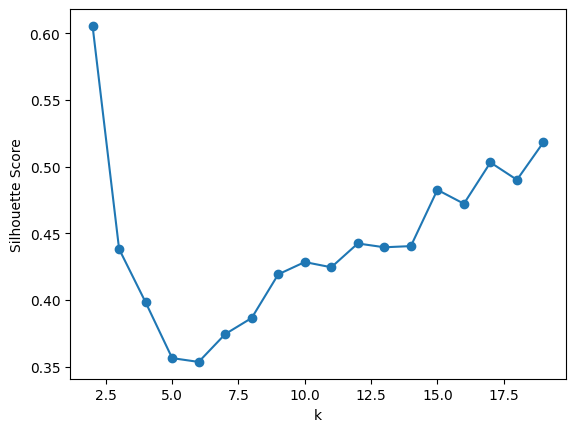

In [27]:
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

In [37]:
inercia = []
for i in silhouette_scores:
    inercia.append(i)
    

In [31]:
print(inercia)

[np.float64(0.6055089618561077), np.float64(0.4381585450078779), np.float64(0.39705280988017827), np.float64(0.35632018427663514), np.float64(0.379973178772362), np.float64(0.3740956297052553), np.float64(0.40226523023943767), np.float64(0.39599966254000146), np.float64(0.43777454066973875), np.float64(0.42941615798735666), np.float64(0.4537431168316178), np.float64(0.48004958480933024), np.float64(0.47913424040905594), np.float64(0.4733754890958995), np.float64(0.5022883437108483), np.float64(0.48830739576943616), np.float64(0.5032707508534164), np.float64(0.5366871501763512)]


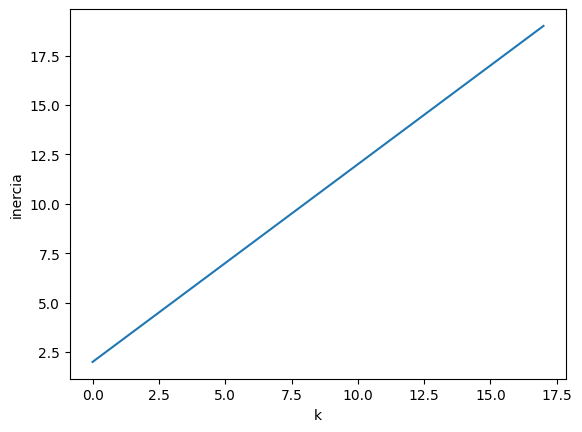

In [32]:
plt.plot(range(2,20))
plt.xlabel('k')
plt.ylabel('inercia')
plt.show()


#### Genera el K Means 

In [13]:
k = 10

kmeans = KMeans(n_clusters=k, n_init=10, random_state=11)

y_pred = kmeans.fit_predict(data_scaled)

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters. 